# Imports / Dependencies / Ingest  

In [1]:
# Dependencies & Imports
# ======================

# Python standard libraries
import os
import urllib.request

# Data handling & visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PySpark core & SQL functions
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.functions import (
    hour, count, mean, col, when, unix_timestamp,
    round as spark_round,
    dayofweek, sin, cos, lit
)

# Statistical smoothing
from statsmodels.nonparametric.smoothers_lowess import lowess



# Spark ML utilities
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

# scikit-learn for sampling, splitting, and metrics
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Hyperparameter distributions
from scipy.stats import randint, uniform

# Native LightGBM
import lightgbm as lgb

from pyspark.sql.functions import rand, mean as _mean, col


In [2]:
# Initialize SparkSession with SynapseML JAR

try: spark.stop()
except: pass

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

spark = (
    SparkSession.builder
      .appName("NYC Yellow Taxi + SynapseML")
      .config(
          "spark.jars.packages",
          "com.microsoft.azure:synapseml_2.12:0.10.2"
      )
      .getOrCreate()
)

print(" Spark with SynapseML ready")


 Spark with SynapseML ready


In [ ]:
#ingest data


# Set environment variables for Java
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# Create Spark session
spark = SparkSession.builder \
    .appName("NYC Yellow Taxi Analysis") \
    .getOrCreate()

parquet_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
local_path = "/tmp/yellow_tripdata_2023-01.parquet"
urllib.request.urlretrieve(parquet_url, local_path)

# Now read from the local file with Spark
df_spark = spark.read.parquet(local_path)
df_spark.printSchema()
df_spark.show(5)

# For lightgbm modeling locally, convert to pandas DataFrame (sample for memory)
df_pd = df_spark.limit(50000).toPandas()  # You can adjust the number of rows as needed

# Preview pandas DataFrame
df_pd.head()

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+----

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


# Data Cleaning and Preprocessing

In [4]:
# add all the additional features to data

df_spark_final = (
    df_spark
    # tip percentage & trip duration
    .withColumn(
        "tip_pct",
        when(col("fare_amount") > 0,
             col("tip_amount") / col("fare_amount") * 100)
        .otherwise(0)
    )
    .withColumn(
        "trip_time_minutes",
        spark_round(
            (unix_timestamp(col("tpep_dropoff_datetime")) -
             unix_timestamp(col("tpep_pickup_datetime"))) / 60,
            2
        )
    )


    # cyclic hour of day using F.pi()
    .withColumn("pickup_hour", hour(col("tpep_pickup_datetime")))
    .withColumn("hour_sin", sin(2 * F.pi() * col("pickup_hour") / lit(24)))
    .withColumn("hour_cos", cos(2 * F.pi() * col("pickup_hour") / lit(24)))
    # day of week & weekend flag
    .withColumn("day_of_week", dayofweek(col("tpep_pickup_datetime")))
    .withColumn("is_weekend", when(col("day_of_week").isin(1,7), 1).otherwise(0))
    # fare per minute & per mile
    .withColumn("fare_per_min", col("fare_amount") / col("trip_time_minutes"))
    .withColumn("fare_per_mile", col("fare_amount") / col("trip_distance"))
)

# Sanity-check
df_spark_final \
  .select(
     "tip_pct","trip_time_minutes",
     "hour_sin","hour_cos",
     "day_of_week","is_weekend",
     "fare_per_min","fare_per_mile",
     "PULocationID","DOLocationID"
  ) \
  .show(5, False)

df_spark_unfiltered = df_spark_final

+------------------+-----------------+--------+--------+-----------+----------+------------------+------------------+------------+------------+
|tip_pct           |trip_time_minutes|hour_sin|hour_cos|day_of_week|is_weekend|fare_per_min      |fare_per_mile     |PULocationID|DOLocationID|
+------------------+-----------------+--------+--------+-----------+----------+------------------+------------------+------------+------------+
|0.0               |8.43             |0.0     |1.0     |1          |1         |1.1032028469750892|9.587628865979383 |161         |141         |
|50.632911392405056|6.32             |0.0     |1.0     |1          |1         |1.25              |7.181818181818182 |43          |237         |
|100.67114093959731|12.75            |0.0     |1.0     |1          |1         |1.1686274509803922|5.936254980079682 |48          |238         |
|0.0               |9.62             |0.0     |1.0     |1          |1         |1.2577962577962578|6.368421052631579 |138         |7     

In [ ]:
# clean out extreme values

df_spark_final = df_spark_final.filter(
    (col("fare_amount") > 3) &
    (col("fare_amount") < 200) &
    (col("tip_amount") >= 0) &
    (col("tip_pct") >= 0) &
    (col("tip_pct") <= 100) &
    (col("RatecodeID")==1)&
    (col("trip_time_minutes")>=0)&
    (col("trip_time_minutes")<=800)&
    (col("tolls_amount")>=0)&
    (col("tolls_amount")<=50)&
    (col("trip_distance") > 0)&
    (col("trip_distance") < 35)

)

df_spark_final.select("tip_pct").describe().show()

+-------+-----------------+
|summary|          tip_pct|
+-------+-----------------+
|  count|          2785198|
|   mean|20.73641590254792|
| stddev|13.72855508976887|
|    min|              0.0|
|    max|            100.0|
+-------+-----------------+



We have negative tip percentages which likely come from refunds, corrections, or data errors. Similarly the massive tip percentages likely arise from similarly rare circumstantial instances.

Additionally since the minimum fare is \$3 I'll remove entries with fares below \$3.

Also we'll exclude some obvious value ssuch as negative time or negative tolls.

Additionally we'll only do ratecode 1

The data with distance ==0 and >100 look odd and I think we will not gain much from it but variability. As such I'll filter out entries with distance of 0 or 100.

In [6]:
# print total loss of data from cleaning

prev_count = df_spark.count()
final_count = df_spark_final.count()

percent_remaining = final_count / prev_count * 100
percent_removed = 100 - percent_remaining

print(f"Rows before distance filter: {prev_count}")
print(f"Rows after distance filter:  {final_count}")
print(f"Percentage remaining:         {percent_remaining:.2f}%")
print(f"Percentage removed:           {percent_removed:.2f}%")


Rows before distance filter: 3066766
Rows after distance filter:  2785198
Percentage remaining:         90.82%
Percentage removed:           9.18%


# EDA

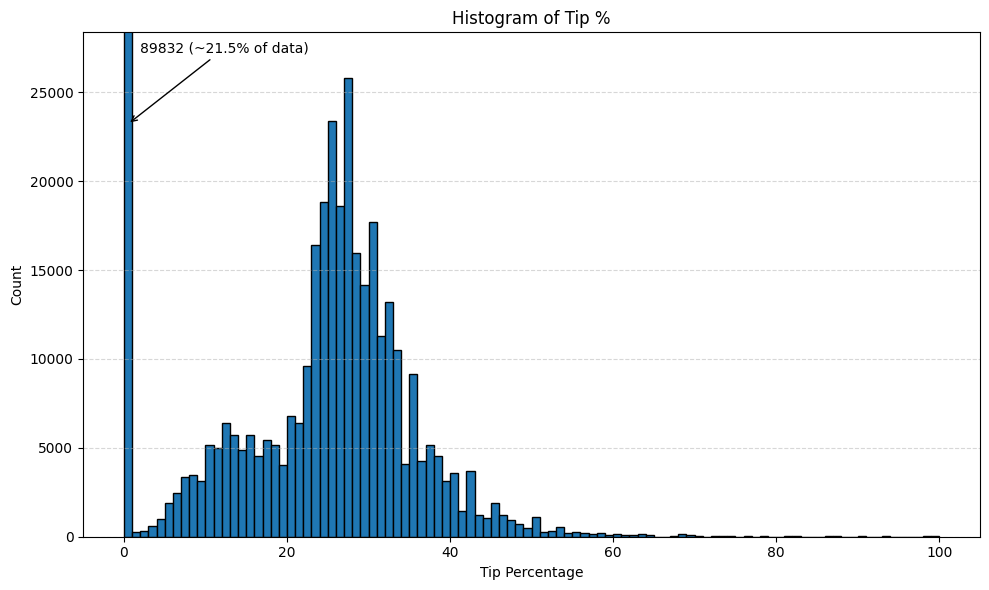

In [ ]:
# Simple histogram

# Sample 15% of cleaned Spark DataFrame and pull tip_pct into pandas
pdf_hist = (
    df_spark_final
      .sample(fraction=0.15, seed=42)
      .select("tip_pct")
      .toPandas()
)

# Compute histogram counts and bins
counts, bins = np.histogram(pdf_hist["tip_pct"], bins=100, range=(0, 100))

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = bins[1] - bins[0]
ax.bar(bins[:-1], counts, width=bar_width, edgecolor='k', align='edge')

# Zoom y-axis to focus on non-zero bins
max_nonzero = counts[1:].max()
ax.set_ylim(0, max_nonzero * 1.1)

# Compute zero-tip count and percentage
zero_count = counts[0]
total_count = counts.sum()
pct_zero = zero_count / total_count * 100

# Annotate the zero bin with count and percent
text = f'{zero_count} (~{pct_zero:.1f}% of data)'
arrow_x = bins[0] + bar_width/2
arrow_y = max_nonzero * 0.9
text_x = bins[1] + bar_width
text_y = max_nonzero * 1.05

ax.annotate(
    text,
    xy=(arrow_x, arrow_y),
    xytext=(text_x, text_y),
    ha='left',
    va='bottom',
    arrowprops=dict(arrowstyle='->')
)

ax.set_xlabel("Tip Percentage")
ax.set_ylabel("Count")
ax.set_title("Histogram of Tip %")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

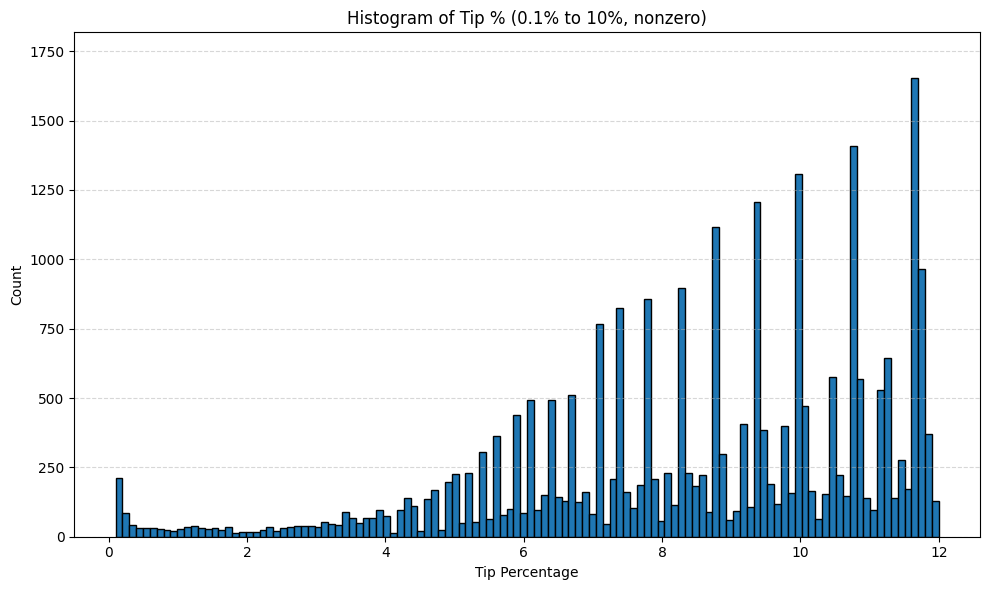

In [ ]:
# Filter for nonzero tips between 0.1 and 10%
pdf_hist_filtered = pdf_hist[(pdf_hist["tip_pct"] >= 0.1) & (pdf_hist["tip_pct"] <= 12)]

# Compute histogram counts and bins
counts, bins = np.histogram(pdf_hist_filtered["tip_pct"], bins=120, range=(0.1, 12))

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = bins[1] - bins[0]
ax.bar(bins[:-1], counts, width=bar_width, edgecolor='k', align='edge')

# Zoom y-axis to focus on non-zero bins
if counts.max() > 0:
    ax.set_ylim(0, counts.max() * 1.1)

ax.set_xlabel("Tip Percentage")
ax.set_ylabel("Count")
ax.set_title("Histogram of Tip % (0.1% to 10%, nonzero)")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


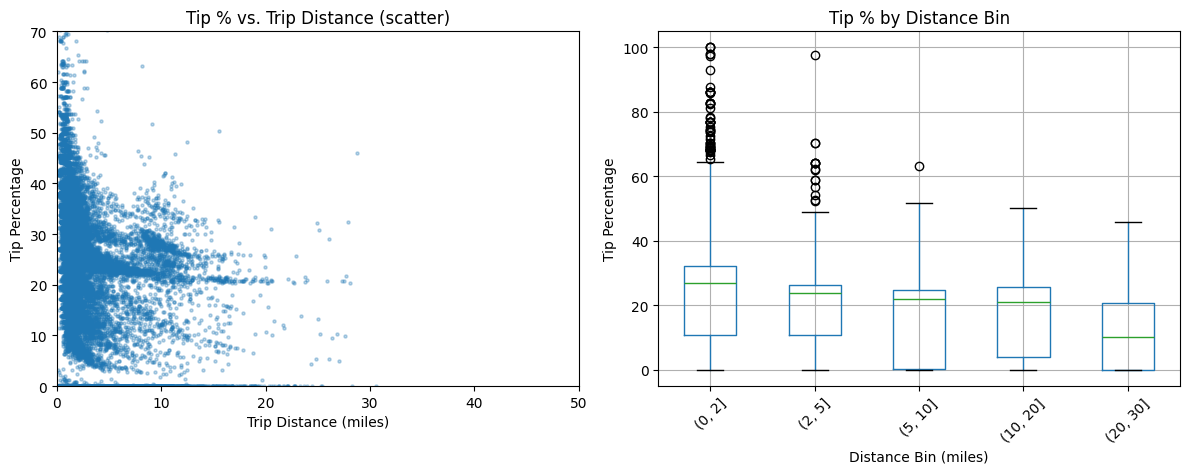

In [9]:
#  tip% vs distance


df_dist_pct = (
    df_spark_final
      .select("trip_distance", "tip_pct")
      .sample(fraction=0.01, seed=24)
      .toPandas()
)

# Bin distances
bins = [0, 2, 5, 10, 20, 30]
df_dist_pct['dist_bin'] = pd.cut(df_dist_pct["trip_distance"], bins=bins)

# Create exactly 1×2 subplots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Left: scatter
axs[0].scatter(
    df_dist_pct["trip_distance"],
    df_dist_pct["tip_pct"],
    alpha=0.3,
    s=5
)
axs[0].set_xlim(0, 50)
axs[0].set_ylim(0, 70)
axs[0].set_xlabel("Trip Distance (miles)")
axs[0].set_ylabel("Tip Percentage")
axs[0].set_title("Tip % vs. Trip Distance (scatter)")

# Right: binned boxplot
df_dist_pct.boxplot(
    column="tip_pct",
    by="dist_bin",
    ax=axs[1],
    rot=45
)
axs[1].set_title("Tip % by Distance Bin")
axs[1].set_xlabel("Distance Bin (miles)")
axs[1].set_ylabel("Tip Percentage")
plt.suptitle("")

plt.tight_layout()
plt.show()

Above in the scatter plot we can see a clear non-linear increase in the tip as the distance shortened. Likely due to riders being more comfortable tipping a higher percentage when the distance (and therefore the fare) are lower thus requiring a lower absolute cost of the tip. Additionally it seems as distance (and therefore fare) increases there are fewer outliers.

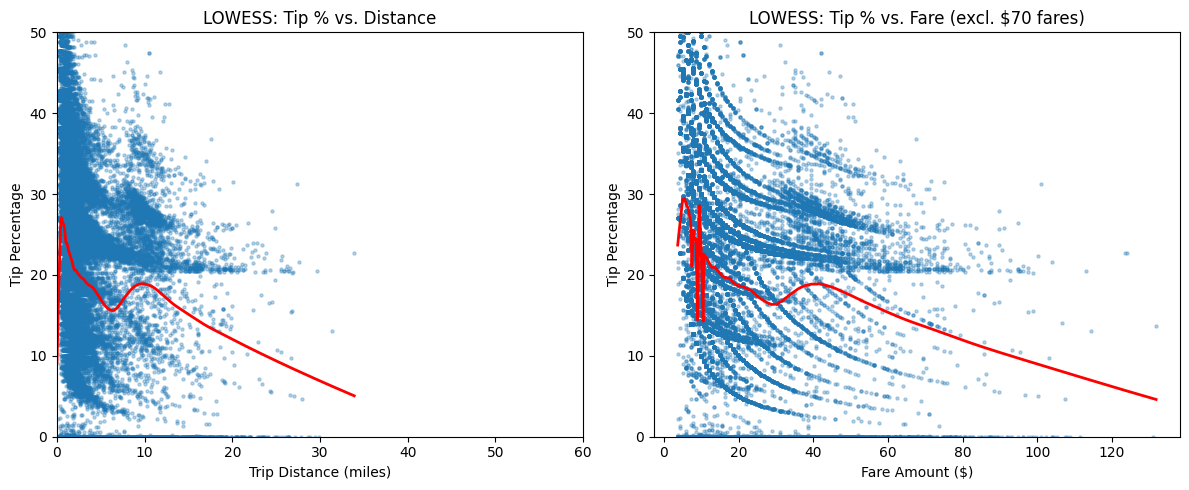

In [ ]:
# average tip % vs distance and fare

#  Sample from Spark (already cleaned & filtered)
pdf = (
    df_spark_final
      .select("trip_distance", "fare_amount", "tip_pct")
      .sample(fraction=0.02, seed=42)
      .toPandas()
)

# Remove fixed-route fare of $70
pdf = pdf[pdf["fare_amount"] != 70]

# Fit LOWESS curves with smoothing fraction
frac = 0.1
lowess_dist = lowess(pdf["tip_pct"], pdf["trip_distance"], frac=frac)
lowess_fare = lowess(pdf["tip_pct"], pdf["fare_amount"], frac=frac)

#  Plot scatter + smooth (smooth line in red)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Tip % vs Distance (max 60 miles)
ax1.scatter(pdf["trip_distance"], pdf["tip_pct"], alpha=0.3, s=5)
ax1.plot(lowess_dist[:, 0], lowess_dist[:, 1], color='red', linewidth=2)
ax1.set_xlim(0, 60)
ax1.set_ylim(0, 50)
ax1.set_xlabel("Trip Distance (miles)")
ax1.set_ylabel("Tip Percentage")
ax1.set_title("LOWESS: Tip % vs. Distance")

# Tip % vs Fare (excluding $70 fares)
ax2.scatter(pdf["fare_amount"], pdf["tip_pct"], alpha=0.3, s=5)
ax2.plot(lowess_fare[:, 0], lowess_fare[:, 1], color='red', linewidth=2)
ax2.set_ylim(0, 50)
ax2.set_xlabel("Fare Amount ($)")
ax2.set_ylabel("Tip Percentage")
ax2.set_title("LOWESS: Tip % vs. Fare (excl. $70 fares)")

plt.tight_layout()
plt.show()

Both distance and fare plots have an interesting bump at 10 miles and 47ish dollars.

In [ ]:
# inspecting interesting hike

df_spark_final \
  .filter((col("trip_distance") >= 9) & (col("trip_distance") < 11)) \
  .groupBy("PULocationID", "DOLocationID") \
  .agg(
    count("*").alias("trip_count"),
    mean("tip_pct").alias("avg_tip_pct")
  ) \
  .orderBy(col("trip_count").desc()) \
  .show(10)

+------------+------------+----------+------------------+
|PULocationID|DOLocationID|trip_count|       avg_tip_pct|
+------------+------------+----------+------------------+
|         138|         230|      2925|22.031460174451905|
|         138|         161|      1870|23.977610992856373|
|         138|         239|      1571| 23.91964266905977|
|         138|         163|      1377| 22.98933376464707|
|         138|         162|      1342|23.791006100470227|
|         230|         138|      1238|21.798855234346494|
|         161|         138|      1203| 23.00387535427717|
|         138|          48|      1192|21.087569101769418|
|         138|         237|      1115|24.534718412085823|
|         138|         229|      1076| 23.17660929116658|
+------------+------------+----------+------------------+
only showing top 10 rows



Filtering between 9 and 11 miles we see the the most common pickup and drop off pairs. All of these are either picking up from or dropping off to Location ID 138 which corresponds to LaGuardia Airport which likely explains the increased tipping percentage

In [12]:
# inspect how hour of day may effect tipping


total_count = df_spark_final.count()

hourly_stats = (
    df_spark_final
      .withColumn("pickup_hour", hour("tpep_pickup_datetime"))
      .groupBy("pickup_hour")
      .agg(
          spark_round(mean("tip_pct"), 2).alias("avg_tip_pct"),
          count("*").alias("trip_count")
      )
      .withColumn(
          "pct_of_total",
          spark_round(col("trip_count") / total_count * 100, 2)
      )
      .orderBy(col("pct_of_total").desc())
)

hourly_stats.show(24, False)





+-----------+-----------+----------+------------+
|pickup_hour|avg_tip_pct|trip_count|pct_of_total|
+-----------+-----------+----------+------------+
|18         |22.66      |199424    |7.16        |
|17         |22.1       |190060    |6.82        |
|15         |19.54      |178009    |6.39        |
|19         |22.56      |177805    |6.38        |
|16         |21.54      |175856    |6.31        |
|14         |19.48      |172657    |6.2         |
|13         |19.54      |162541    |5.84        |
|12         |19.67      |155892    |5.6         |
|20         |21.83      |152592    |5.48        |
|21         |21.87      |148585    |5.33        |
|11         |19.61      |142359    |5.11        |
|22         |21.29      |134991    |4.85        |
|10         |19.7       |132373    |4.75        |
|9          |20.1       |119957    |4.31        |
|8          |20.26      |105100    |3.77        |
|23         |20.74      |103768    |3.73        |
|0          |20.42      |76920     |2.76        |


Average tip vs time of day shows us that the busiest time of day is also the time with the highest tips.

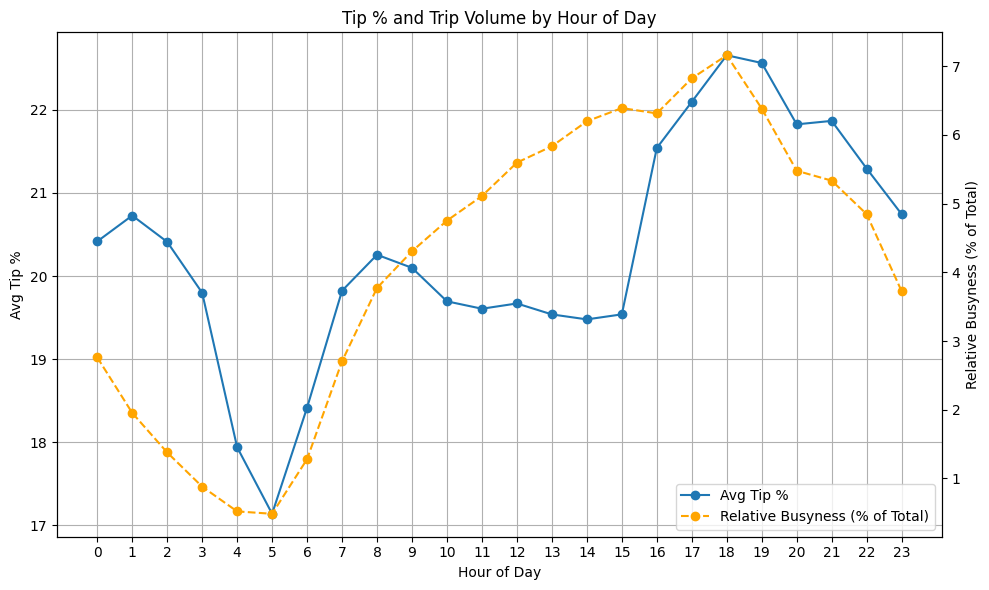

In [ ]:
# Compute hourly stats (again or reuse previous df)
total_count = df_spark_final.count()
hourly_stats = (
    df_spark_final
      .withColumn('pickup_hour', hour('tpep_pickup_datetime'))
      .groupBy('pickup_hour')
      .agg(
          mean('tip_pct').alias('avg_tip_pct'),
          count('*').alias('trip_count')
      )
      .withColumn('pct_of_total', F.col('trip_count') / total_count * 100)
      .orderBy('pickup_hour')
      .toPandas()
)

# Dual‐axis line chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Avg Tip %
ax1.plot(
    hourly_stats['pickup_hour'],
    hourly_stats['avg_tip_pct'],
    marker='o',
    linestyle='-',
    label='Avg Tip %'
)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Avg Tip %')
ax1.set_xticks(range(24))
ax1.grid(True)

# Trip Volume (% of Total) on second y-axis
ax2 = ax1.twinx()
ax2.plot(
    hourly_stats['pickup_hour'],
    hourly_stats['pct_of_total'],
    marker='o',
    linestyle='--',
    color='orange',
    label='Relative Busyness (% of Total)'
)
ax2.set_ylabel('Relative Busyness (% of Total)')

# Combined legend in bottom right
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title('Tip % and Trip Volume by Hour of Day')
plt.tight_layout()
plt.show()


As seen in the plot above, there is a decent corrolation between the busiest hours and the average tip percentage but there are some clear deviations in between the two. Just to spitball it could be that people who take taxi's during working hours seem to tip less than the busyness of the hour would imply possibly because they take them so consistently that tipping becomes less of a priority

In [ ]:
#  Compute correlations only for relevant numeric features in Spark



# List of truly numeric, continuous columns
numeric_cols = [
    "passenger_count",
    "trip_distance",
    "trip_time_minutes",
    "extra",
    "tolls_amount",
    "congestion_surcharge",
    "airport_fee",
    "fare_per_min",
    "fare_per_mile",
    "hour_sin",
    "hour_cos",
    "day_of_week",
    "is_weekend"
]

# Compute and print Pearson correlation with tip_pct
for c in numeric_cols:
    corr_val = df_spark_final.stat.corr("tip_pct", c)
    print(f"{c:20s} : {corr_val:.4f}")


passenger_count      : -0.0169
trip_distance        : -0.1499
trip_time_minutes    : -0.1624
extra                : 0.0633
tolls_amount         : 0.0027
congestion_surcharge : 0.1509
airport_fee          : -0.0875
fare_per_min         : 0.0042
fare_per_mile        : 0.0310
hour_sin             : -0.0623
hour_cos             : 0.0455
day_of_week          : 0.0089
is_weekend           : -0.0310


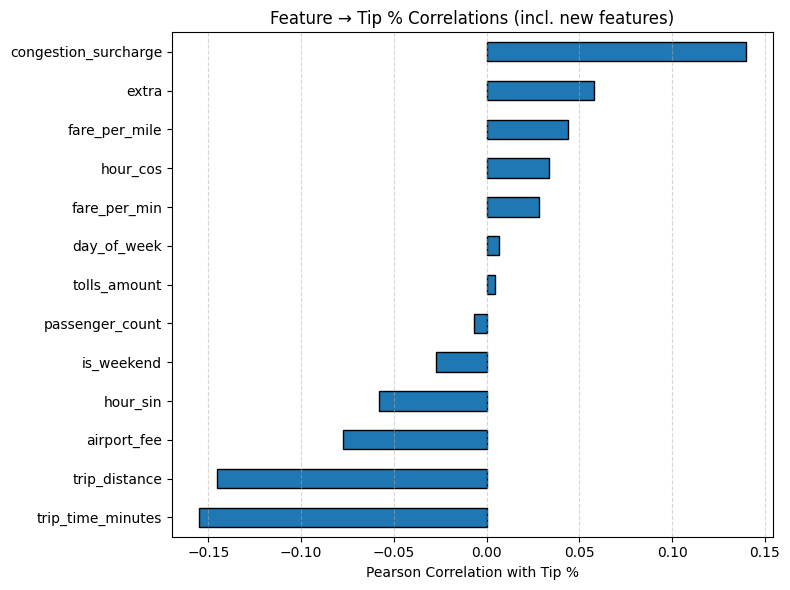

In [ ]:
#  Bar chart of correlations including new numeric features


# Update the list of numeric features
numeric_cols = [
    "passenger_count",
    "trip_distance",
    "trip_time_minutes",
    "extra",
    "tolls_amount",
    "congestion_surcharge",
    "airport_fee",
    "fare_per_min",      # this and below are new-----------------------------
    "fare_per_mile",
    "hour_sin",
    "hour_cos",
    "day_of_week",
    "is_weekend"
]

# Pull a 1% sample and compute correlations
sample_pdf = (
    df_spark_final
      .select(numeric_cols + ["tip_pct"])
      .sample(fraction=0.01, seed=42)
      .toPandas()
)

corr_series = sample_pdf.corr()["tip_pct"].drop("tip_pct").sort_values()

plt.figure(figsize=(8, 6))
corr_series.plot(kind="barh", edgecolor='k')
plt.xlabel("Pearson Correlation with Tip %")
plt.title("Feature → Tip % Correlations (incl. new features)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


The congestion surcharge is mostly around more expensive higher density parts of town which explains it's high correlation with tip %. The extra category is a catchall for extra charges such as late-night, bad weather etc. Most people tip on service not the toal cost so the toll is only slightly positively correlated.

# Train Model

In [ ]:


# Sample & collect
pdf = df_spark_final.sample(fraction=0.10, seed=42).toPandas()

#  Feature lists
num_cols = [
    "passenger_count","trip_distance","trip_time_minutes",
    "extra","tolls_amount","congestion_surcharge","airport_fee",
    "fare_per_min","fare_per_mile","hour_sin","hour_cos",
    "day_of_week","is_weekend"
]
cat_cols = ["payment_type","VendorID","PULocationID","DOLocationID"]

# Build X, y
X_num = pdf[num_cols]
X_cat = pd.get_dummies(pdf[cat_cols].astype(str), prefix=cat_cols)
X = pd.concat([X_num, X_cat], axis=1)
y = pdf["tip_pct"]

#  Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  LightGBM datasets
dtrain = lgb.Dataset(X_train, label=y_train)
dtest  = lgb.Dataset(X_test,  label=y_test, reference=dtrain)

#  Train with early stopping
params = {
    "objective": "regression",
    "metric":    "rmse",
    "learning_rate":    0.1,
    "num_leaves":       31,
    "bagging_fraction": 0.8,
    "feature_fraction": 0.8,
    "verbose":         -1
}
model = lgb.train(
    params,
    dtrain,
    num_boost_round=200,
    valid_sets=[dtest],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20),
        lgb.log_evaluation(period=10)
    ]
)


preds = model.predict(X_test, num_iteration=model.best_iteration)
print("Baseline RMSE = %.2f pp" % mean_squared_error(y_test, preds)**0.5)
print("Baseline R²   = %.3f"   % r2_score(y_test, preds))


Training until validation scores don't improve for 20 rounds
[10]	valid_0's rmse: 9.4585
[20]	valid_0's rmse: 8.83569
[30]	valid_0's rmse: 8.67643
[40]	valid_0's rmse: 8.64393
[50]	valid_0's rmse: 8.63495
[60]	valid_0's rmse: 8.63106
[70]	valid_0's rmse: 8.62985
[80]	valid_0's rmse: 8.6291
[90]	valid_0's rmse: 8.62853
[100]	valid_0's rmse: 8.62859
[110]	valid_0's rmse: 8.62784
[120]	valid_0's rmse: 8.62753
[130]	valid_0's rmse: 8.62734
[140]	valid_0's rmse: 8.62712
[150]	valid_0's rmse: 8.62744
Early stopping, best iteration is:
[137]	valid_0's rmse: 8.62675
Baseline RMSE = 8.63 pp
Baseline R²   = 0.606
